In [11]:
import jax.numpy as jnp 
import jax as j
import matplotlib.pyplot as plt


In [12]:
A = 1.0 
alpha = 0.7 
gamma = 0.8
epsilon = 0.08
v0 = 0.0
w0 = 0.0
d = 0.01 #difusao


h = 0.1 #passos de tempo
delta_x = 0.1 #passo espacial

xf = 1.0
tf = 20.0 #tempo final

t = jnp.arange(0, tf + h, h)
x = jnp.arange(0, xf + delta_x, delta_x)


In [13]:
def I_ion(v,w,t,iamp):
    iapp = jnp.where((t >= 1.0) & (t <= 2.0), iamp, 0.0)
    return v - (v**3)/3.0 - w + iapp

def g(v,w):
    return epsilon*(v + alpha - gamma*w) 


# estimulo = jnp.zeros(len(x))
# for i in range(len(x)):
#     if x[i] <= 0.1:
#         estimulo = estimulo.at[i].set(5.0)
#     else:
#         estimulo = estimulo.at[i].set(0.0)

estimulo = jnp.where(x<= 0.1, 5.0, 0.0) 

def passo(estado,t):
    V, W = estado
    dvdt = d*(V[2:] - 2*V[1:-1] +V[:-2])/delta_x**2 + I_ion(V[1:-1], W[1:-1], t, estimulo[1:-1]) 
    dwdt = g(V[1:-1], W[1:-1])

    V = V.at[1:-1].set(V[1:-1] + dvdt * h)
    W = W.at[1:-1].set(W[1:-1] + dwdt * h)

    V = V.at[0].set(V[1])
    V = V.at[-1].set(V[-2])
   
    W = W.at[0].set(W[0]+h*g(V[0], W[0]))
    W = W.at[-1].set(W[-1]+h*g(V[-1], W[-1]))

    return (V, W) , (V, W)




#V0 = jnp.full(len(x), -1.2) #jnp.full cria um array com um valor especifico, precisamos passar o estado inicial como array para o scan, nao como escalares
#W0 = jnp.full(len(x), -0.62) # primeiro argumento eh o tamanho e o segundo eh o valor que queremos preencher o array


W0 = jnp.zeros(len(x)) 
V0 = jnp.zeros(len(x))

V0 = V0.at[:].set(-1.2)
W0 = W0.at[:].set(-0.62)


solucao, historico = j.lax.scan(passo,(V0,W0), t) #jax.lax.scan so recebe 3 argumentos(funcao, estado_inicial, array_de_tempo)

V = historico[0]
W = historico[1]

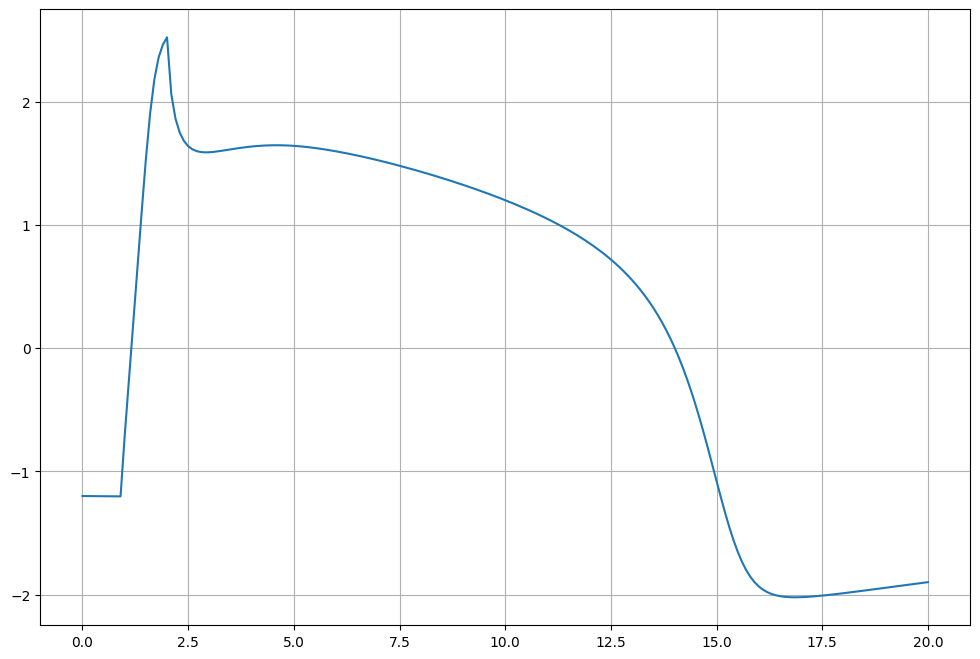

In [14]:
plt.figure(figsize=(12, 8))
plt.plot(t,V[:,1])
plt.grid(True)
plt.show()

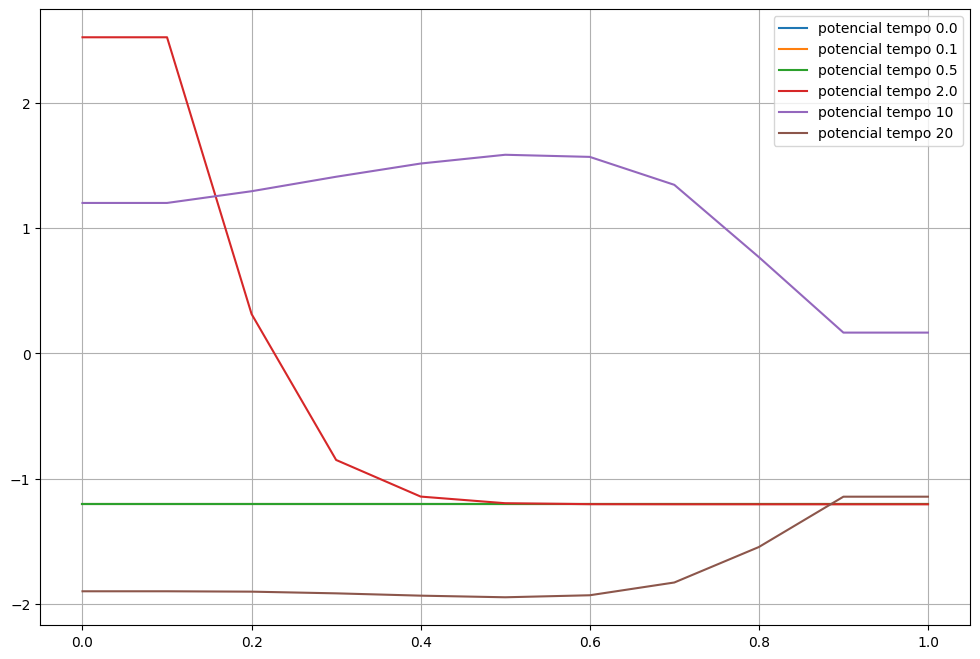

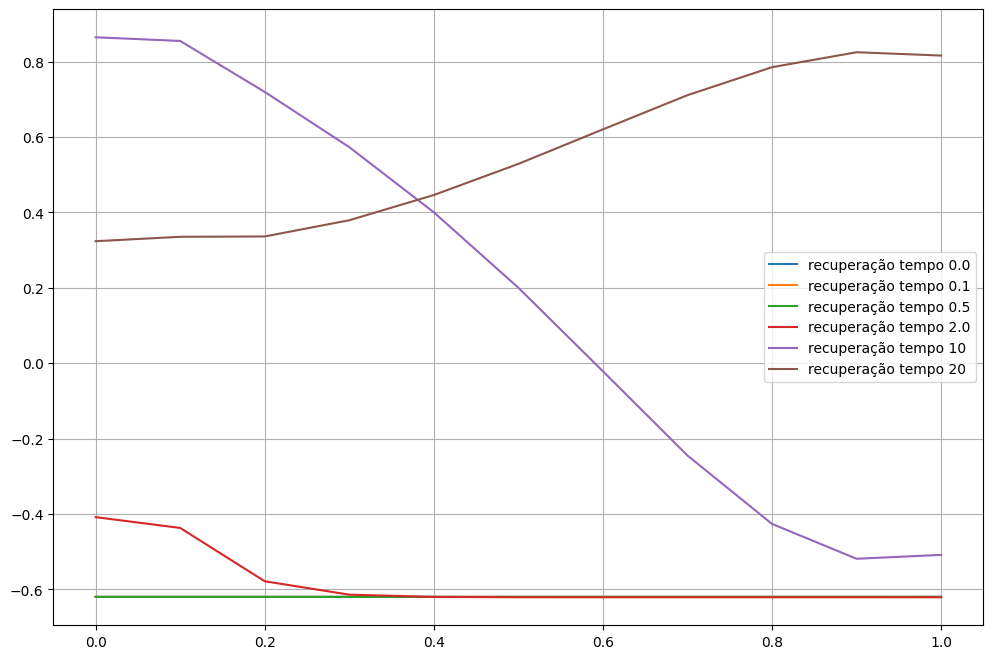

In [15]:
V = historico[0]
W = historico[1]

t_plot = [0.0, 0.1, 0.5, 2.0,10,20]


plt.figure(figsize=(12, 8))

for t in t_plot:
    plt.plot(x, V[int(t/h)],label = 'potencial tempo {}'.format(t))
    
plt.legend() 
plt.grid(True)
plt.show() 




plt.figure(figsize=(12, 8))

for t in t_plot:
    plt.plot(x, W[int(t/h)],label = 'recuperação tempo {}'.format(t))
    
plt.legend() 
plt.grid(True)
plt.show()



